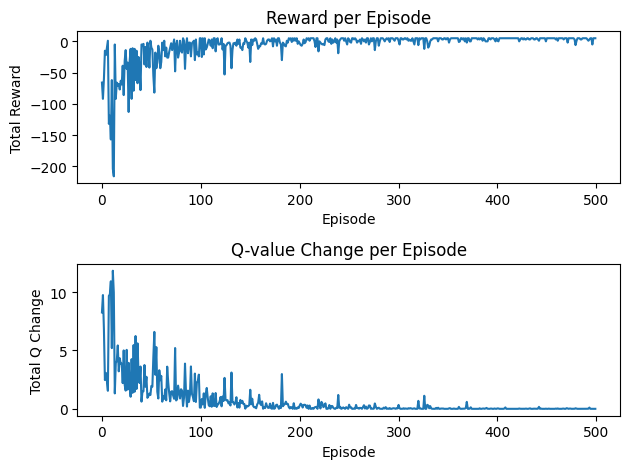

In [1]:
# q_learning_convergence.py

import numpy as np
import random
import matplotlib.pyplot as plt

# Grid size
ROWS = 4
COLS = 4

actions = ["up", "down", "left", "right"]

# Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.1
episodes = 500

# Rewards
goal_reward = 10
step_penalty = -1
wall_penalty = -5

goal_state = (3, 3)

# Q-table
Q = {(i, j): {a: 0 for a in actions} for i in range(ROWS) for j in range(COLS)}

# Tracking metrics
rewards_per_episode = []
q_changes_per_episode = []


def get_next_state(state, action):
    i, j = state

    if action == "up":
        i -= 1
    elif action == "down":
        i += 1
    elif action == "left":
        j -= 1
    elif action == "right":
        j += 1

    if i < 0 or i >= ROWS or j < 0 or j >= COLS:
        return state, wall_penalty

    if (i, j) == goal_state:
        return (i, j), goal_reward

    return (i, j), step_penalty


# Training
for episode in range(episodes):

    state = (0, 0)
    total_reward = 0
    total_q_change = 0

    while state != goal_state:

        # Action selection
        if random.random() < epsilon:
            action = random.choice(actions)
        else:
            action = max(Q[state], key=Q[state].get)

        next_state, reward = get_next_state(state, action)

        # Q update
        old_q = Q[state][action]

        max_future_q = max(Q[next_state].values())
        new_q = old_q + alpha * (reward + gamma * max_future_q - old_q)

        Q[state][action] = new_q

        # Track change
        total_q_change += abs(new_q - old_q)

        total_reward += reward
        state = next_state

    rewards_per_episode.append(total_reward)
    q_changes_per_episode.append(total_q_change)

    epsilon = max(min_epsilon, epsilon * epsilon_decay)


# Plotting
plt.figure()

# Reward plot
plt.subplot(2, 1, 1)
plt.plot(rewards_per_episode)
plt.title("Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")

# Q-change plot
plt.subplot(2, 1, 2)
plt.plot(q_changes_per_episode)
plt.title("Q-value Change per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Q Change")

plt.tight_layout()
plt.show()